# CS 3110/5110: Data Privacy

## In-Class Exercise #3, week of 9/21/2026


In [1]:
# Load the data and libraries
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

adult = pd.read_csv(
    "https://github.com/jnear/cs3110-data-privacy/raw/main/homework/adult_with_pii.csv"
)

## Question 5

Consider the program below.


In [2]:
counting_query = lambda: 1
epsilon1 = 1
epsilon2 = 2

result_1 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon1)
result_2 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon2)
result_3 = counting_query() + np.random.laplace(loc=0, scale=1 / epsilon1)

print(result_1, result_2, result_3)

1.4336543366747563 2.0045133721531534 1.6683405186039828


Write a function `total_epsilon` that returns the total privacy cost for this program.


In [3]:
def total_epsilon():
    # In Differential Privacy, the total epsilon for sequential composition is the sum of individual epsilons.
    return epsilon1 + epsilon2 + epsilon1

In [4]:
assert total_epsilon() == 4

## Question 1

Implement the Laplace mechanism below.


In [5]:
def laplace_mech(v, sensitivity, epsilon):
    return v + np.random.laplace(loc=0, scale=sensitivity / epsilon)

In [6]:
# TEST CASE for question 1
dist1 = [laplace_mech(50, 1, 1.0) for _ in range(200)]
dist2 = [np.random.laplace(loc=50, scale=1) for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 2

Write a differentially private function to return the number of people over the
age of 30.


In [7]:
def people_over_30_dp():
    count = len(adult[adult["Age"] > 30])
    return laplace_mech(count, sensitivity=1, epsilon=1)


people_over_30_dp()

# This is a counting query so the sensitivity is 1.

21987.59836971455

In [8]:
# TEST CASE for question 2
dist1 = [np.random.laplace(loc=21989, scale=1.0) for _ in range(200)]
dist2 = [people_over_30_dp() for _ in range(200)]

assert stats.wasserstein_distance(dist1, dist2) < 1

## Question 3

Consider the following definition of a differencing attack (without differential privacy).


In [9]:
def differencing_attack():
    q1 = adult["Age"].sum()
    q2 = adult[adult["Name"] != "Karrie Trusslove"]["Age"].sum()

    return q1 - q2


print("Differencing attack result:", differencing_attack())

Differencing attack result: 39


Implement a function `dp_differencing_attack` that performs the same attack, but attempts to satisfy differential privacy using the Laplace mechanism. Use the parameters `sensitivity=1` and `epsilon=1.0`.


In [18]:
def dp_differencing_attack():
    q1 = adult["Age"].sum()
    q2 = adult[adult["Name"] != "Karrie Trusslove"]["Age"].sum()

    # The total epsilon is 1.0 because we are splitting it equally between the two queries.
    noisy_q1 = laplace_mech(q1, sensitivity=1, epsilon=0.5)
    noisy_q2 = laplace_mech(q2, sensitivity=1, epsilon=0.5)

    return noisy_q1 - noisy_q2


print("DP Differencing attack result:", dp_differencing_attack())


# THE SENSITIVITY HERE IS WRONG AND THEREFORE DOES NOT PROTECT AGAINST THIS
# ATTACK.
# Diff. Priv. promises that I can remove Karrie's row and the output should not
# change significantly; however, here it does. Again, this is a demonstration of why correctly setting the sensitivity is crucial for differential privacy.

DP Differencing attack result: 41.77735765790567


In [20]:
# TEST CASE for question 1
dp_results = [dp_differencing_attack() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=1) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 2

## Question 4

What is the _sensitivity_ of the `differencing_attack` query defined above, and why?


The sensitivity of the sum in general is unbounded.
In this case, we can assume ages are always upper-bounded b y 120, so the
sensitivity is 120.


## Question 5

Implement a corrected version of `dp_differencing_attack` that uses the correct sensitivity and thus correctly satisfies differential privacy.


In [ ]:
def dp_differencing_attack_corrected():
    q1 = adult["Age"].sum()
    q2 = adult[adult["Name"] != "Karrie Trusslove"]["Age"].sum()

    # The total epsilon is 1.0 because we are splitting it equally between the two queries.
    noisy_q1 = laplace_mech(q1, sensitivity=120, epsilon=0.5)
    noisy_q2 = laplace_mech(q2, sensitivity=120, epsilon=0.5)

    # noisy_q1 = laplace_mech(q1, sensitivity=120, epsilon=0.5)
    # noisy_q2 = laplace_mech(q2, sensitivity=120, epsilon=0.5)

    return noisy_q1 - noisy_q2


print("DP Differencing attack result:", dp_differencing_attack_corrected())

DP Differencing attack result: 281.4338412929792


In [27]:
# TEST CASE for question 3
dp_results = [dp_differencing_attack_corrected() for _ in range(100)]
spec = [np.random.laplace(loc=39, scale=125 / 2.0) for _ in range(100)]
assert stats.wasserstein_distance(dp_results, spec) < 200
assert stats.wasserstein_distance(dp_results, spec) > 50

## Question 6

Write a function `dp_mean_age` that calculates the mean age of members of the dataset.


In [15]:
def mean_age():
    return adult["Age"].mean()


mean_age()

np.float64(38.58164675532078)

In [30]:
def dp_mean_age(epsilon):
    # return laplace_mech(mean_age(), sensitivity=120, epsilon=epsilon)

    noisy_sum = laplace_mech(
        adult["Age"].sum(), sensitivity=120, epsilon=epsilon / 2
    )
    noisy_count = laplace_mech(len(adult), sensitivity=1, epsilon=epsilon / 2)
    return noisy_sum / noisy_count

In [31]:
# TEST CASE for question 1
results = [dp_mean_age(1) for _ in range(100)]
assert np.abs(np.mean(results) - mean_age()) < 0.1

## Question 7

Write a function `dp_age_sum_clipping` that uses clipping to bound the sensitivity of the sum of ages.


In [ ]:
def dp_age_sum_clipping(epsilon, b):
    clipped_ages = adult["Age"].clip(lower=0, upper=b)
    # sensitivity becomes the upper bound.
    return laplace_mech(clipped_ages.sum(), sensitivity=b, epsilon=epsilon)


dp_age_sum_clipping(1.0, 100)

np.float64(1256239.8101524774)

In [33]:
# TEST CASE for question 2
results = [dp_age_sum_clipping(1.0, 100) for _ in range(10)]
assert np.abs(np.mean(results) - adult["Age"].sum()) < 100

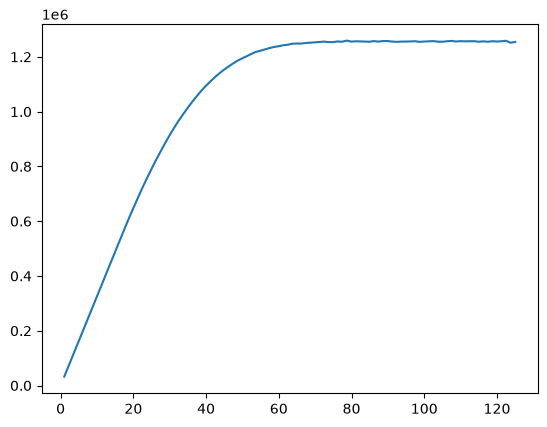

In [ ]:
bs = np.linspace(1, 125, 100)
results = [dp_age_sum_clipping(0.1, b) for b in bs]
plt.plot(bs, results)

# baseline = [adult['Age'].sum() for b in bs]
# plt.plot(bs, baseline);

# This graph is useful to help us decide what the clipping parameter should be,
# but producing this graph is doing biasing based on the data. So to truly use
# this would be adding a lot of epsilon to the overall privacy budget.